# Clustering avec DBSCAN sur le Dataset CreditDataSet

Ce notebook présente une analyse de clustering utilisant l'algorithme DBSCAN (Density-Based Spatial Clustering of Applications with Noise) sur le dataset CreditDataSet.

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

## 1. Présentation de DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) est un algorithme de clustering basé sur la densité qui peut identifier des clusters de formes variées.

### Concepts clés:

- **ε (epsilon)**: Distance maximale entre deux points pour qu'ils soient considérés comme voisins
- **MinPts**: Nombre minimum de points nécessaires pour former un cluster dense
- **Point central (core point)**: Point ayant au moins MinPts voisins dans un rayon ε
- **Point de bord (border point)**: Point dans le voisinage d'un point central mais n'ayant pas assez de voisins
- **Point de bruit (noise point)**: Point qui n'est ni central ni de bord

### Avantages:
- Peut découvrir des clusters de formes arbitraires
- Pas besoin de spécifier le nombre de clusters à l'avance
- Robuste aux outliers (les traite comme du bruit)

### Limitations:
- Ne fonctionne pas bien lorsque la densité varie à travers les clusters
- Sensible aux paramètres ε et MinPts

## 2. Chargement et préparation des données

In [2]:
# Chargement du dataset CreditDataSet
df = pd.read_csv('CreditDataSet.csv')
print(f"Forme du dataset: {df.shape}")

# Suppression de la colonne CUST_ID
df_model = df.drop('CUST_ID', axis=1).copy()

# Gestion des valeurs manquantes dans MINIMUM_PAYMENTS
payments_mean = np.mean(df_model['PAYMENTS'])
for idx, row in df_model.iterrows():
    if pd.isna(row['MINIMUM_PAYMENTS']):
        if row['PAYMENTS'] == 0:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = 0
        elif 0 < row['PAYMENTS'] < payments_mean:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = row['PAYMENTS']
        else:
            df_model.loc[idx, 'MINIMUM_PAYMENTS'] = payments_mean

# Suppression des lignes avec des valeurs manquantes restantes
df_model = df_model.dropna().reset_index(drop=True)
print(f"Forme après nettoyage: {df_model.shape}")

# Normalisation des données (importante pour DBSCAN)
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_model), 
    columns=df_model.columns
)
print("Données normalisées avec succès!")

Forme du dataset: (8950, 18)
Forme après nettoyage: (8949, 17)
Données normalisées avec succès!


## 3. Détermination des paramètres optimaux (ε et MinPts)

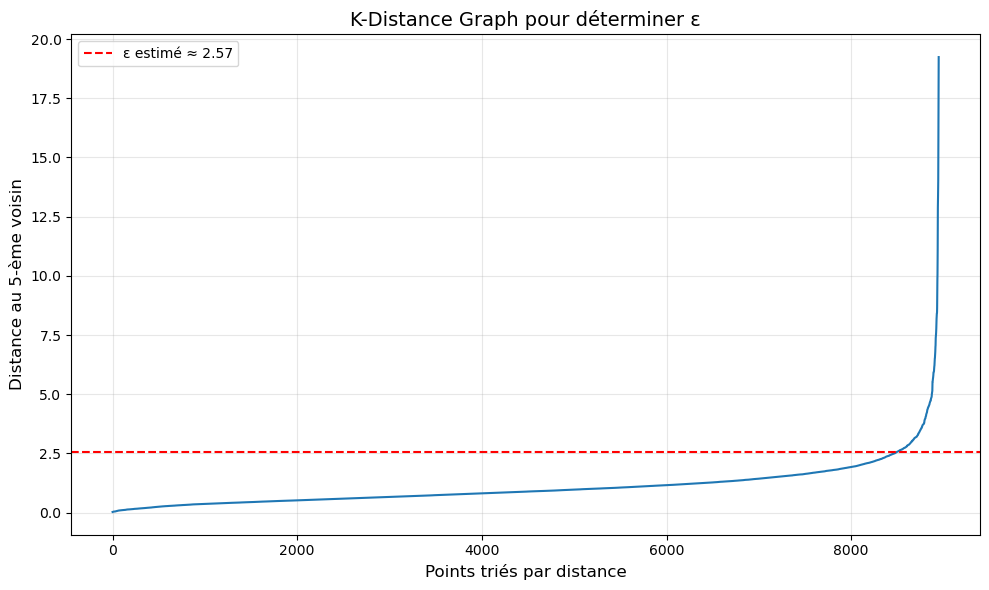

Estimation de ε (epsilon): 2.5742
MinPts (min_samples): 5


In [3]:
# Méthode du k-distance graph pour déterminer ε
# On calcule la distance au k-ème plus proche voisin pour chaque point
min_samples = 4  # MinPts = min_samples + 1 (car on compte le point lui-même)

neighbors = NearestNeighbors(n_neighbors=min_samples + 1)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)

# Trier les distances au k-ème voisin (dernière colonne)
distances = np.sort(distances, axis=0)
distances = distances[:, min_samples]  # Distance au k-ème voisin

# Visualisation du k-distance graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Points triés par distance', fontsize=12)
plt.ylabel(f'Distance au {min_samples + 1}-ème voisin', fontsize=12)
plt.title('K-Distance Graph pour déterminer ε', fontsize=14)
plt.grid(True, alpha=0.3)

# Trouver le "coude" dans la courbe (point d'inflexion)
# On cherche le point où la courbe change de pente
knee_point = int(len(distances) * 0.95)  # Approximativement 95% des points
eps_estimate = distances[knee_point]
plt.axhline(y=eps_estimate, color='r', linestyle='--', 
           label=f'ε estimé ≈ {eps_estimate:.2f}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Estimation de ε (epsilon): {eps_estimate:.4f}")
print(f"MinPts (min_samples): {min_samples + 1}")

## 4. Application de DBSCAN

In [4]:
# Application de DBSCAN avec les paramètres estimés
eps_value = 0.5  # Vous pouvez ajuster selon le k-distance graph
min_samples_value = 5  # MinPts

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
cluster_labels = dbscan.fit_predict(df_scaled)

# Ajouter les labels au DataFrame
df_model['cluster'] = cluster_labels

# Statistiques sur les clusters
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)

print(f"Nombre de clusters trouvés: {n_clusters}")
print(f"Nombre de points de bruit (outliers): {n_noise}")
print(f"Pourcentage de bruit: {n_noise/len(cluster_labels)*100:.2f}%")
print(f"\nRépartition des clusters:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Nombre de clusters trouvés: 36
Nombre de points de bruit (outliers): 6629
Pourcentage de bruit: 74.08%

Répartition des clusters:
-1     6629
 0     1946
 1        8
 2       34
 3       11
 4        6
 5        9
 6       13
 7       23
 8       14
 9        8
 10      60
 11       7
 12       8
 13       6
 14      23
 15      29
 16       5
 17       7
 18       5
 19       7
 20       5
 21       9
 22       5
 23       6
 24       5
 25       5
 26       8
 27       7
 28       5
 29      10
 30       5
 31       5
 32       4
 33       3
 34       4
 35       5
Name: count, dtype: int64


In [5]:
# Statistiques descriptives par cluster (en excluant le bruit)
if n_clusters > 0:
    print("Statistiques descriptives par cluster:")
    cluster_stats = df_model[df_model['cluster'] != -1].groupby('cluster').mean()
    print(cluster_stats)
else:
    print("Aucun cluster trouvé avec ces paramètres. Essayez d'ajuster eps ou min_samples.")

Statistiques descriptives par cluster:
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                  
0         872.386387           0.900962   196.742713         71.631403   
1         984.442150           0.875000     0.000000          0.000000   
2          20.262235           0.336898   227.378529         46.333235   
3          49.632927           1.000000   618.156364          0.001818   
4          45.130583           1.000000   239.420000          0.000000   
5          35.499760           0.909091   382.776667         14.777778   
6          10.185994           0.335664    92.749231          0.000000   
7        4939.878369           1.000000     8.913478          4.565217   
8        1323.174786           0.987013     7.811429          7.811429   
9          27.333807           0.681818   310.178750          0.000000   
10         18.357674           0.580303   207.604000         10.248000   

## 5. Visualisation des résultats

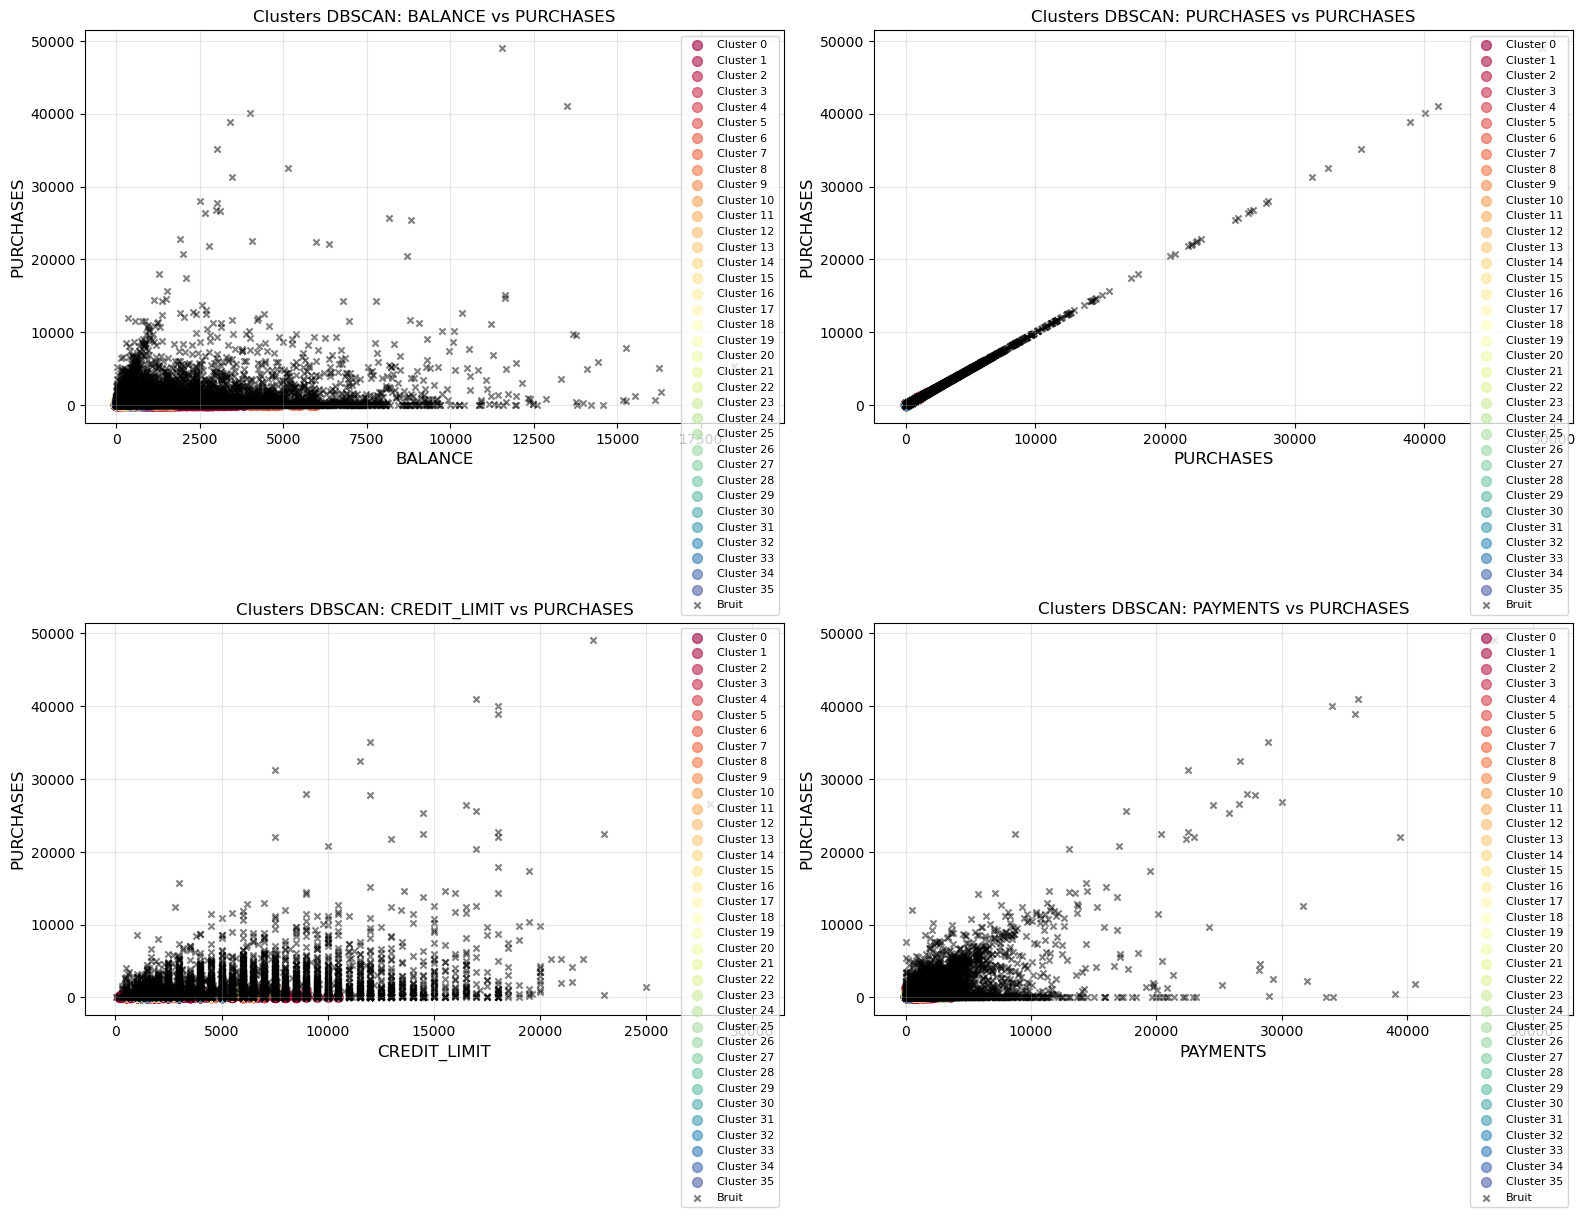

In [6]:
# Visualisation des clusters DBSCAN
important_vars = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Créer une palette de couleurs pour les clusters
unique_labels = set(cluster_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
color_map = dict(zip(unique_labels, colors))

for idx, var in enumerate(important_vars):
    ax = axes[idx]
    
    # Tracer chaque cluster
    for label in unique_labels:
        if label == -1:
            # Points de bruit en noir
            cluster_data = df_model[df_model['cluster'] == label]
            ax.scatter(cluster_data[var], cluster_data['PURCHASES'], 
                      c='black', marker='x', s=20, alpha=0.5, label='Bruit')
        else:
            cluster_data = df_model[df_model['cluster'] == label]
            ax.scatter(cluster_data[var], cluster_data['PURCHASES'], 
                      c=[color_map[label]], label=f'Cluster {label}', 
                      alpha=0.6, s=50)
    
    ax.set_xlabel(var, fontsize=12)
    ax.set_ylabel('PURCHASES', fontsize=12)
    ax.set_title(f'Clusters DBSCAN: {var} vs PURCHASES', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

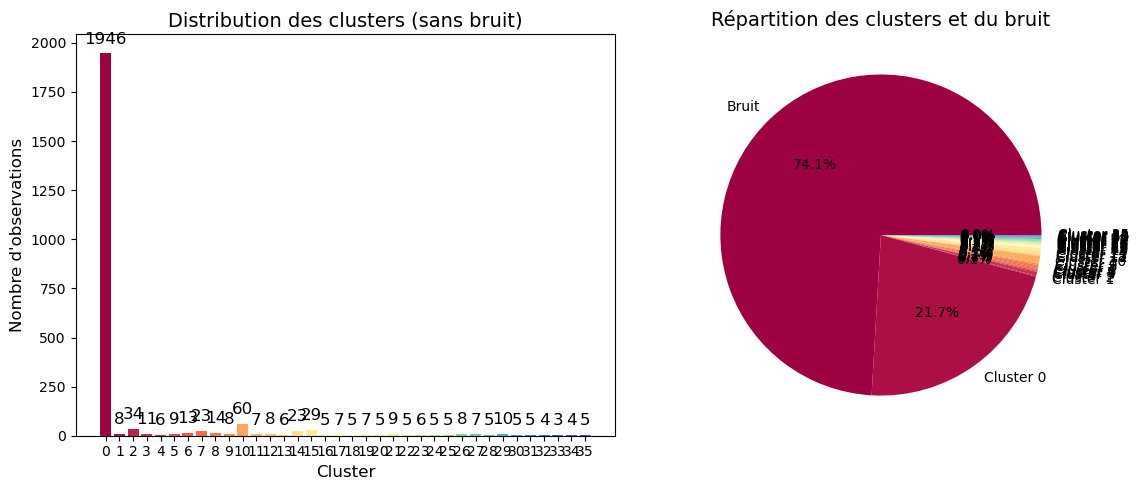

In [7]:
# Distribution des clusters (en excluant le bruit pour la visualisation)
if n_clusters > 0:
    cluster_counts = df_model[df_model['cluster'] != -1]['cluster'].value_counts().sort_index()
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.bar(cluster_counts.index.astype(str), cluster_counts.values, 
           color=plt.cm.Spectral(np.linspace(0, 1, len(cluster_counts))))
    plt.xlabel('Cluster', fontsize=12)
    plt.ylabel('Nombre d\'observations', fontsize=12)
    plt.title('Distribution des clusters (sans bruit)', fontsize=14)
    for i, v in enumerate(cluster_counts.values):
        plt.text(i, v + 50, str(v), ha='center', fontsize=12)
    
    plt.subplot(1, 2, 2)
    # Ajouter le bruit dans le graphique en camembert
    all_counts = pd.Series(cluster_labels).value_counts().sort_index()
    labels_pie = [f'Cluster {i}' if i != -1 else 'Bruit' for i in all_counts.index]
    colors_pie = [plt.cm.Spectral(i/len(all_counts)) if i != -1 else 'black' 
                 for i in range(len(all_counts))]
    plt.pie(all_counts.values, labels=labels_pie, autopct='%1.1f%%', colors=colors_pie)
    plt.title('Répartition des clusters et du bruit', fontsize=14)
    
    plt.tight_layout()
    plt.show()

## 6. Métriques d'évaluation

In [8]:
# Calcul des métriques d'évaluation (en excluant le bruit)
if n_clusters > 1:
    # Filtrer les points de bruit pour le calcul des métriques
    mask = cluster_labels != -1
    df_filtered = df_scaled[mask]
    labels_filtered = cluster_labels[mask]
    
    silhouette = silhouette_score(df_filtered, labels_filtered)
    calinski = calinski_harabasz_score(df_filtered, labels_filtered)
    davies = davies_bouldin_score(df_filtered, labels_filtered)
    
    print("Métriques d'évaluation (sans les points de bruit):")
    print(f"  - Score de Silhouette: {silhouette:.4f}")
    print(f"  - Score de Calinski-Harabasz: {calinski:.4f}")
    print(f"  - Score de Davies-Bouldin: {davies:.4f}")
    print(f"\nParamètres utilisés:")
    print(f"  - ε (eps): {eps_value}")
    print(f"  - MinPts (min_samples): {min_samples_value}")
else:
    print("Pas assez de clusters pour calculer les métriques d'évaluation.")
    print("Essayez d'ajuster les paramètres eps et min_samples.")

Métriques d'évaluation (sans les points de bruit):
  - Score de Silhouette: -0.3757
  - Score de Calinski-Harabasz: 28.9937
  - Score de Davies-Bouldin: 0.9655

Paramètres utilisés:
  - ε (eps): 0.5
  - MinPts (min_samples): 5


## 7. Test avec différents paramètres

DBSCAN est sensible aux paramètres ε et MinPts. Testons différentes combinaisons pour trouver les meilleurs paramètres.

In [ ]:
# Test de différentes combinaisons de paramètres
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples_values = [3, 5, 7, 10]

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan_test = DBSCAN(eps=eps, min_samples=min_samples)
        labels_test = dbscan_test.fit_predict(df_scaled)
        
        n_clusters_test = len(set(labels_test)) - (1 if -1 in labels_test else 0)
        n_noise_test = list(labels_test).count(-1)
        
        if n_clusters_test > 1:
            mask_test = labels_test != -1
            df_filtered_test = df_scaled[mask_test]
            labels_filtered_test = labels_test[mask_test]
            
            silhouette_test = silhouette_score(df_filtered_test, labels_filtered_test)
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters_test,
                'n_noise': n_noise_test,
                'pct_noise': n_noise_test/len(labels_test)*100,
                'silhouette': silhouette_test
            })
        else:
            results.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters_test,
                'n_noise': n_noise_test,
                'pct_noise': n_noise_test/len(labels_test)*100,
                'silhouette': np.nan
            })

results_df = pd.DataFrame(results)
print("Résultats des tests avec différents paramètres:")
print(results_df.round(4))

# Trouver les meilleurs paramètres
if results_df['silhouette'].notna().any():
    best_params = results_df.loc[results_df['silhouette'].idxmax()]
    print(f"\nMeilleurs paramètres selon le score de silhouette:")
    print(f"  - ε (eps): {best_params['eps']}")
    print(f"  - MinPts (min_samples): {int(best_params['min_samples'])}")
    print(f"  - Nombre de clusters: {int(best_params['n_clusters'])}")
    print(f"  - Score de silhouette: {best_params['silhouette']:.4f}")

## 8. Conclusion

DBSCAN est un algorithme puissant pour le clustering basé sur la densité qui présente plusieurs avantages:

- **Détection automatique du nombre de clusters**: Pas besoin de spécifier le nombre de clusters à l'avance
- **Robustesse aux outliers**: Les points de bruit sont identifiés et exclus des clusters
- **Clusters de formes variées**: Contrairement à K-Means, DBSCAN peut identifier des clusters non-sphériques

**Points importants à retenir:**
- Le choix des paramètres ε et MinPts est crucial
- La méthode du k-distance graph aide à déterminer ε
- Les données doivent être normalisées pour de meilleurs résultats
- DBSCAN peut identifier les outliers comme points de bruit